# New York City TLC (Taxi and Limousine Commission) Records

# Latar Belakang 

Transportasi umum seperti taksi di New York memainkan peran penting dalam mobilitas masyarakat. Analisis data perjalanan taksi dapat membantu memahami pola penggunaan transportasi, faktor-faktor yang mempengaruhi biaya, serta preferensi penumpang. Dataset TLC (Taxi and Limousine Commission) memberikan data historis tentang perjalanan, yang bisa digunakan untuk meningkatkan layanan, menentukan tarif yang adil, dan membantu pengambilan keputusan kebijakan transportasi.

# Pernyataan Masalah 

Perusahaan transportasi ingin **mengetahui karakteristik perjalanan taksi di New York City untuk memahami pola perilaku penumpang dan meningkatkan layanan**. Informasi ini akan membantu perusahaan dalam mengurangi biaya operasional, meningkatkan kualitas pelayanan, serta mengoptimalkan strategi penempatan armada taksi. Sebagai seorang *data analyst*, kita akan mencoba menjawab pertanyaan berikut: Bagaimana karakteristik perjalanan taksi di NYC berdasarkan jarak tempuh, waktu perjalanan, lokasi penjemputan dan pengantaran, serta tipe perjalanan (street-hail vs dispatch)?

# Data
Untuk menjawab pertanyaan di atas, kita akan menganalisa data peserta yang sudah dikumpulkan oleh perusahaan. Dataset dapat diakses [di sini](https://drive.google.com/drive/folders/1NYHIL-RgVPW-HONz4pdzlcbIChF-c37N). 

## Import Data

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_1samp, ttest_ind, ttest_rel, f_oneway, chi2_contingency, mannwhitneyu, kruskal, wilcoxon

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

Dataset ini berisi informasi terkait perjalanan New York City TLC, yang dicatat oleh meteran taksi dan sistem penyedia layanan (LPEP). Ada 20 kolom di dalam dataset ini, yaitu:

* VendorID: kode penyedia LPEP yang merekam data (1 = Creative Mobile Technologies, 2 = VeriFone Inc).
* lpep_pickup_datetime: waktu saat argo dinyalakan.
* lpep_dropoff_datetime: waktu saat argo dimatikan.
* store_and_fwd_flag: penanda apakah data disimpan dulu di kendaraan sebelum dikirim ke server (Y = ya, N = tidak).
* RatecodeID: kode tarif akhir (1 = Standard, 2 = JFK, 3 = Newark, 4 = Nassau/Westchester, 5 = Negotiated fare, 6 = Group ride).
* PULocationID: zona TLC tempat penumpang naik.
* DOLocationID: zona TLC tempat penumpang turun.
* passenger_count: jumlah penumpang (input dari pengemudi).
* trip_distance: jarak perjalanan (mil) yang dicatat argo.
* fare_amount: biaya perjalanan berdasarkan argo.
* extra: biaya tambahan (rush hour, overnight).
* mta_tax: pajak MTA otomatis $0.50.
* tip_amount: tip (otomatis jika kartu, cash tidak tercatat).
* tolls_amount: total biaya tol.
* ehail_fee: biaya e-hailing (kolom ada tapi nilainya biasanya kosong).
* improvement_surcharge: biaya tambahan $0.30 sejak 2015.
* total_amount: total biaya perjalanan (tidak termasuk tip cash).
* payment_type: metode pembayaran (1 = Credit card, 2 = Cash, 3 = No charge, 4 = Dispute, 5 = Unknown, 6 = Voided trip).
* trip_type: tipe perjalanan (1 = Street-hail, 2 = Dispatch).
* congestion_surcharge: biaya tambahan kemacetan (diterapkan di NYC sejak 2019).


Berikut 5 baris teratas dan terbawah dari dataset New York City TLC Trip Record.

In [3]:
df = pd.read_csv('NYC_TLC_Trip_Record.csv')
display(df.head(),df.tail())

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,NaN,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,NaN,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,NaN,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,NaN,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,NaN,1.0,8.00,1.0,1.0,0.00


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,0.0,0.0,0.00,0.0,NaN,1.0,16.70,NaN,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,0.0,0.0,0.00,0.0,NaN,1.0,5.41,NaN,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,0.0,0.0,3.51,0.0,NaN,1.0,21.04,NaN,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,0.0,0.0,3.20,0.0,NaN,1.0,19.18,NaN,NaN,NaN
68210,2,2023-01-31 23:51:00,2023-02-01 00:07:00,NaN,NaN,256,140,NaN,5.82,23.65,0.0,0.0,2.00,0.0,NaN,1.0,29.40,NaN,NaN,NaN


## Data Understanding and Cleaning
Sebelum masuk ke dalam analisis, kita perlu mengenal dataset kita lebih jauh dalam tahapan *data understanding*. Dari proses ini, kita akan tahu anomali-anomali apa saja yang terdapat di dalam dataset kita dan perlu ditangani dalam tahapan *data cleaning*. Setiap penangan anomali yang dilakukan, akan disertai dengan justifikasi langkah yang diambil, baik secara *domain knowledge* maupun secara statistik.

Pertama, mari kita lihat informasi umum dari dataset NYC TLC Trip Record.

In [4]:
print(f'Jumlah baris dan kolom di dataset df adalah {df.shape}')
df.info()

Jumlah baris dan kolom di dataset df adalah (68211, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  int64  
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  float64
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-null  float64
 14

In [5]:
display(df.describe(), df.describe(include='object'))

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,68211.000000,63887.000000,68211.000000,68211.000000,63887.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,0.0,68211.000000,68211.000000,63887.000000,63877.000000,63887.000000
mean,1.863028,1.117160,98.549735,138.429901,1.315870,8.114852,16.603545,0.825431,0.588340,2.139012,0.169627,NaN,0.951625,21.789377,1.373613,1.021933,0.726748
std,0.343820,1.372913,61.244314,76.761311,0.979054,585.105955,13.470121,1.269904,0.385819,3.052710,1.099789,NaN,0.196875,15.457115,0.508039,0.146465,1.212836
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,NaN,-1.000000,-71.500000,1.000000,1.000000,-2.750000
25%,2.000000,1.000000,74.000000,74.000000,1.000000,1.110000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,12.900000,1.000000,1.000000,0.000000
50%,2.000000,1.000000,75.000000,138.000000,1.000000,1.850000,13.500000,0.000000,0.500000,1.600000,0.000000,NaN,1.000000,17.900000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,129.000000,219.000000,1.000000,3.210000,19.800000,1.000000,0.500000,3.330000,0.000000,NaN,1.000000,26.150000,2.000000,1.000000,2.750000
max,2.000000,99.000000,265.000000,265.000000,9.000000,120098.840000,490.000000,12.500000,2.750000,222.220000,36.050000,NaN,1.000000,491.000000,5.000000,2.000000,2.750000


,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag
count,68211,68211,63887
unique,66575,66519,2
top,2023-01-09 09:08:00,2023-01-09 00:00:00,N
freq,4,6,63579


In [6]:
pd.set_option('display.max_colwidth', None)

# data uni di tiap kolom
listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

tabel1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=listItem)

tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,VendorID,2,"[2, 1]"
1,lpep_pickup_datetime,66575,"[2023-01-01 00:26:10, 2023-01-01 00:51:03, 2023-01-01 00:35:12, 2023-01-01 00:13:14, 2023-01-01 00:33:04, 2023-01-01 00:53:31, 2023-01-01 00:09:14, 2023-01-01 00:11:58, 2023-01-01 00:41:29, 2023-01-01 00:50:32, 2023-01-01 00:16:12, 2023-01-01 00:08:43, 2023-01-01 00:26:32, 2023-01-01 00:18:35, 2023-01-01 00:39:32, 2023-01-01 00:49:34, 2023-01-01 00:10:45, 2023-01-01 00:35:11, 2023-01-01 00:31:06, 2023-01-01 00:14:37, 2023-01-01 00:26:21, 2023-01-01 00:41:56, 2023-01-01 00:32:02, 2023-01-01 00:55:13, 2023-01-01 00:01:31, 2023-01-01 00:22:31, 2023-01-01 00:57:28, 2023-01-01 00:35:21, 2023-01-01 00:52:52, 2023-01-01 00:32:56, 2023-01-01 00:24:01, 2023-01-01 00:46:48, 2023-01-01 00:40:58, 2023-01-01 00:20:23, 2023-01-01 01:49:24, 2023-01-01 00:41:53, 2023-01-01 00:56:26, 2023-01-01 00:33:10, 2023-01-01 00:58:28, 2023-01-01 00:42:49, 2023-01-01 00:48:21, 2023-01-01 00:08:05, 2023-01-01 00:13:47, 2023-01-01 00:16:10, 2023-01-01 00:04:25, 2023-01-01 00:33:38, 2023-01-01 00:46:08, 2023-01-01 01:00:08, 2023-01-01 00:28:04, 2023-01-01 00:23:04, 2023-01-01 00:34:07, 2023-01-01 00:52:03, 2023-01-01 00:25:31, 2023-01-01 00:53:09, 2023-01-01 00:42:37, 2023-01-01 00:39:52, 2023-01-01 00:15:32, 2023-01-01 00:06:48, 2023-01-01 00:57:15, 2023-01-01 00:14:13, 2023-01-01 00:52:48, 2023-01-01 00:34:13, 2023-01-01 00:44:41, 2023-01-01 00:11:12, 2023-01-01 01:44:43, 2023-01-01 01:04:44, 2023-01-01 01:48:11, 2023-01-01 01:11:39, 2023-01-01 01:54:25, 2023-01-01 01:59:10, 2023-01-01 01:22:35, 2023-01-01 01:37:10, 2023-01-01 01:46:22, 2023-01-01 01:59:48, 2023-01-01 01:09:49, 2023-01-01 01:23:35, 2023-01-01 01:53:20, 2023-01-01 01:32:14, 2023-01-01 01:01:05, 2023-01-01 01:34:41, 2023-01-01 01:52:08, 2023-01-01 01:49:28, 2023-01-01 01:03:59, 2023-01-01 01:13:11, 2023-01-01 01:40:06, 2023-01-01 01:33:50, 2023-01-01 01:45:19, 2023-01-01 01:51:29, 2023-01-01 01:34:07, 2023-01-01 01:10:08, 2023-01-01 01:32:17, 2023-01-01 01:48:28, 2023-01-01 01:30:43, 2023-01-01 01:51:10, 2023-01-01 01:09:36, 2023-01-01 01:19:54, 2023-01-01 01:31:10, 2023-01-01 01:42:30, 2023-01-01 00:57:51, 2023-01-01 01:27:36, ...]"
2,lpep_dropoff_datetime,66519,"[2023-01-01 00:37:11, 2023-01-01 00:57:49, 2023-01-01 00:41:32, 2023-01-01 00:19:03, 2023-01-01 00:39:02, 2023-01-01 01:11:04, 2023-01-01 00:26:39, 2023-01-01 00:24:55, 2023-01-01 00:46:26, 2023-01-01 01:13:42, 2023-01-01 00:41:43, 2023-01-01 00:17:08, 2023-01-01 00:45:31, 2023-01-01 00:30:09, 2023-01-01 01:18:06, 2023-01-01 01:08:23, 2023-01-01 00:19:37, 2023-01-01 01:17:35, 2023-01-01 00:42:23, 2023-01-01 00:21:50, 2023-01-01 00:30:26, 2023-01-01 00:46:06, 2023-01-01 00:41:25, 2023-01-01 00:59:47, 2023-01-01 00:16:02, 2023-01-01 00:39:24, 2023-01-01 01:09:31, 2023-01-01 00:53:49, 2023-01-01 01:00:53, 2023-01-01 00:42:53, 2023-01-01 00:32:05, 2023-01-01 01:08:17, 2023-01-01 01:04:32, 2023-01-01 00:24:32, 2023-01-01 01:57:51, 2023-01-01 00:41:58, 2023-01-01 01:14:41, 2023-01-01 00:43:08, 2023-01-01 01:14:46, 2023-01-01 00:51:53, 2023-01-01 01:23:50, 2023-01-01 00:13:26, 2023-01-01 00:25:57, 2023-01-01 00:54:55, 2023-01-01 00:17:50, 2023-01-01 00:38:51, 2023-01-01 00:59:10, 2023-01-01 01:05:46, 2023-01-01 00:43:45, 2023-01-01 23:18:32, 2023-01-01 00:50:01, 2023-01-01 00:57:56, 2023-01-01 00:38:40, 2023-01-01 01:13:35, 2023-01-01 00:47:15, 2023-01-01 00:48:54, 2023-01-01 00:23:03, 2023-01-01 01:08:47, 2023-01-01 01:00:15, 2023-01-01 00:25:43, 2023-01-01 01:21:19, 2023-01-01 00:43:57, 2023-01-01 00:48:26, 2023-01-01 00:38:12, 2023-01-01 01:57:31, 2023-01-01 01:11:23, 2023-01-01 02:05:51, 2023-01-01 01:41:21, 2023-01-01 02:05:19, 2023-01-01 02:11:36, 2023-01-01 01:25:11, 2023-01-01 01:41:30, 2023-01-01 02:04:14, 2023-01-01 02:05:29, 2023-01-01 01:17:55, 2023-01-01 01:53:43, 2023-01-01 02:27:01, 2023-01-01 01:43:55, 2023-01-01 01:13:02, 2023-01-01 02:00:06, 2023-01-01 02:00:57, 2023-01-01 02:13:18, 2023-01-01 01:07:17, 2023-01-01 01:26:01, 2

Secara umum, kita bisa melihat bahwa:
* dataset NYC TLC Trip Record memiliki 20 kolom dan 68211 baris.
* beberapa kolom, yaitu, `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`, `trip_type`, `congestion_surcharge` dan `ehail_fee` memiliki data kosong. Data kosong pada kolom-kolom tersebut diwakili dengan data NaN.
* kolom `ehail_fee` bahkan memiliki 100% missing value, sehingga kolom ini bisa dihapus saja karena tidak memiliki data sama sekali.
* kolom `lpep_pickup_datetime` dan `lpep_dropoff_datetime` memiliki data tipe object. Dari penjelasannya, kolom ini seharusnya berisikan data date_time.
* kolom `fare_amount`,`extra`,`mta_tax`,`tip_amount`,`improvement_surcharge`,`total_amount` dan `congestion_surcharge` memiliki nilai minimal negatif, sehingga perlu dianalisis lebih dalam karena tidak masuk akal, seharusnya nilai paling minimal adalah 0 dan tidak mungkin menjadi negatif.
* kolom `passenger_count` memiliki nilai minimal 0, sehingga sangat tidak masuk akal dan akan dilakukan analisis lebih dalam juga.
* kolom `PULocationID` dan `trip_distance` memiliki mean dan median yang selisih jauh, dan akan dilakukan analisis lebih dalam untuk memudahkan analisis.

In [7]:
# Mengubah type data kolom `lpep_pickup_datetime` dan `lpep_dropoff_datetime` dari object menjadi date time

df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])

In [8]:
# persentase missing value di tiap kolom
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

ehail_fee                100.000000
trip_type                  6.353814
congestion_surcharge       6.339154
store_and_fwd_flag         6.339154
RatecodeID                 6.339154
payment_type               6.339154
passenger_count            6.339154
tip_amount                 0.000000
total_amount               0.000000
improvement_surcharge      0.000000
tolls_amount               0.000000
VendorID                   0.000000
mta_tax                    0.000000
lpep_pickup_datetime       0.000000
fare_amount                0.000000
trip_distance              0.000000
DOLocationID               0.000000
PULocationID               0.000000
lpep_dropoff_datetime      0.000000
extra                      0.000000
dtype: float64

<Axes: >

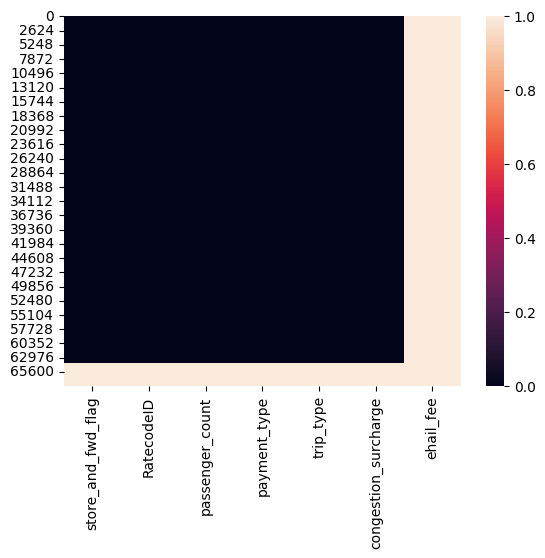

In [9]:
# Sebaran missing value di dalam data

sns.heatmap(df[['store_and_fwd_flag','RatecodeID','passenger_count','payment_type','trip_type','congestion_surcharge','ehail_fee']].isna())

Secara garis besar:  
* *missing value* di kolom `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`,`trip_type` dan `congestion_surcharge` memiliki keterkaitan proporsi yang cukup rendah, dengan missing value kurang dari 7%.
* *missing value* di kolom `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`,dan `congestion_surcharge` memiliki sebaran yang terlihat berkaitan, jika data di `store_and_fwd_flag` kosong, maka kolom `RatecodeID`, `passenger_count`, `payment_type`,dan `congestion_surcharge` juga kosong.
* *missing value* di kolom `ehail_fee` mencapai 100%, sudah dipastikan kolom tersebut tidak ada data, maka kolom tersebut akan dihapus.

Ada 2 cara untuk menangani *missing value*:
* pertama, menghapus baris/kolom yang berisi *missing value*. Cara ini akan dilakukan untuk kolom `ehail_fee` karena missing value mencapai 100%, sudah dipastikan kolom tersebut kosong dan tidak akan mempengaruhi hasil analisis.
* kedua, mengisi data yang hilang. Cara ini lebih disarankan. Ada beberapa metode yang bisa digunakan untuk mengisi missing value, cara yang paling baik adalah dengan mengisi data yang hilang dengan nilai sebenarnya, atau sedekat mungkin dengan nilai asli. Dalam kasus ini, kita akan mencoba mengisi *missing value* berdasarkan kolom lain yang secara domain knowledge atau secara statistik berkaitan dengan kolom yang memiliki *missing value*. Jika masih ada kolom yang tidak bisa diisi, barulah kita mengisi dengan angka *mean, median* atau *modus*. Menghapus data akan menjadi opsi terakhir.

Dari data analisis di atas, *missing value* di kolom `ehail_fee` mencapai 100%, sudah dipastikan kolom tersebut tidak ada data, maka kolom tersebut akan dihapus.

In [10]:
# Hapus kolom 'ehail_fee' 

df.drop('ehail_fee',axis=1,inplace=True)
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,1.0,0.5,4.03,0.0,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,1.0,0.5,2.64,0.0,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,1.0,0.5,1.94,0.0,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,0.5,1.5,1.70,0.0,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,0.5,1.5,0.00,0.0,1.0,8.00,1.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,0.0,0.0,0.00,0.0,1.0,16.70,NaN,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,0.0,0.0,0.00,0.0,1.0,5.41,NaN,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,0.0,0.0,3.51,0.0,1.0,21.04,NaN,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,0.0,0.0,3.20,0.0,1.0,19.18,NaN,NaN,NaN


Dari analisis di atas juga, kita sudah tau bahwa *missing value* `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`,dan `congestion_surcharge` saling berkaitan. Maka, kita akan memutuskan cara pengisian kedua kolom ini secara bersamaan. 

In [11]:
# jumlah missing value di kolom 'store_and_fwd_flag','RatecodeID', 'passenger_count', 'payment_type' dan 'congestion_surcharge'
df[['store_and_fwd_flag','RatecodeID', 'passenger_count', 'payment_type','congestion_surcharge']].isna().sum()

store_and_fwd_flag      4324
RatecodeID              4324
passenger_count         4324
payment_type            4324
congestion_surcharge    4324
dtype: int64

In [12]:
# jumlah kandidat dengan data kosong di 'store_and_fwd_flag','RatecodeID', 'passenger_count', 'payment_type' dantrip_type 'congestion_surcharge' berdasarkan 'trip_type'
display(df[df['store_and_fwd_flag'].isna()]['trip_type'].value_counts(), 
        df[df['RatecodeID'].isna()]['trip_type'].value_counts(), 
        df[df['passenger_count'].isna()]['trip_type'].value_counts(), 
        df[df['payment_type'].isna()]['trip_type'].value_counts(), 
        df[df['congestion_surcharge'].isna()]['trip_type'].value_counts())

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)

Berdasarkan hasil output diatas dan visual dari heatmap menunjukkan kolom *missing value* tidak muncul apapun berdasarkan format kolom `trip_type` maka, akan dilanjutkan dengan pengecekkan baris ke berapa yang memang kosong, karena ada kemungkinan untuk baris yang kosong pada kolom `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`,`trip_type` dan `congestion_surcharge` memiliki angka yg berurutan. Berikut adalah hasilnya :

In [13]:
cols = ['store_and_fwd_flag', 'RatecodeID', 'passenger_count', 'payment_type', 'congestion_surcharge']

# cek baris yang ada missing value di kolom-kolom tersebut
missing_rows = df[df[cols].isnull().any(axis=1)]
missing_rows

# tampilkan index baris yang missing
print(missing_rows.index.to_flat_index())

Index([63887, 63888, 63889, 63890, 63891, 63892, 63893, 63894, 63895, 63896,
       ...
       68201, 68202, 68203, 68204, 68205, 68206, 68207, 68208, 68209, 68210],
      dtype='int64', length=4324)


Sudah dipastikan untuk kolom `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`,`trip_type` dan `congestion_surcharge` pada baris 63887-68210 full berisi missing value. Dilihat dari total missing value yang masih cukup rendah (6,339%) dan dilihat dari banyaknya kolom juga tidak mungkin untuk diisi dengan data lain, karena akan menampilkan data yang bias, maka dari itu untuk baris 63887-68210 akan dihapus.

In [14]:
# hapus baris dari 63887 sampai 68210

df.drop(df.index[63887:68211],inplace=True)
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,1.0,8.00,1.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63882,2,2023-01-31 23:09:22,2023-01-31 23:17:21,N,5.0,130,205,1.0,2.75,15.0,0.0,0.0,2.00,0.0,0.3,17.30,1.0,2.0,0.00
63883,2,2023-01-31 23:06:18,2023-01-31 23:17:03,N,1.0,65,181,1.0,2.44,13.5,1.0,0.5,3.20,0.0,1.0,19.20,1.0,1.0,0.00
63884,2,2023-01-31 23:17:03,2023-01-31 23:23:04,N,1.0,244,116,1.0,1.40,9.3,1.0,0.5,2.36,0.0,1.0,14.16,1.0,1.0,0.00
63885,2,2023-01-31 23:29:18,2023-01-31 23:38:50,N,1.0,74,238,1.0,2.47,13.5,1.0,0.5,3.75,0.0,1.0,22.50,1.0,1.0,2.75


Pada kolom `trip_type`, masih terdapat data kosong (0,016%) dari total keseluruhan data. Proporsi ini sangat kecil sehingga penghapusan maupun pengisian nilai kosong sebenarnya tidak akan berdampak signifikan terhadap keseluruhan dataset. Namun, karena kolom `trip_type` akan dijadikan variabel acuan utama dalam analisis, maka untuk menghindari potensi bias data, keputusan yang lebih bijak adalah menghapus 10 baris tersebut dari dataset.

In [15]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

trip_type                0.015653
VendorID                 0.000000
extra                    0.000000
payment_type             0.000000
total_amount             0.000000
improvement_surcharge    0.000000
tolls_amount             0.000000
tip_amount               0.000000
mta_tax                  0.000000
fare_amount              0.000000
lpep_pickup_datetime     0.000000
trip_distance            0.000000
passenger_count          0.000000
DOLocationID             0.000000
PULocationID             0.000000
RatecodeID               0.000000
store_and_fwd_flag       0.000000
lpep_dropoff_datetime    0.000000
congestion_surcharge     0.000000
dtype: float64

In [16]:
# menghapus missing value yang tersisa di kolom 'trip_type'

df.dropna(subset=['trip_type'],inplace=True)
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,1.0,8.00,1.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63882,2,2023-01-31 23:09:22,2023-01-31 23:17:21,N,5.0,130,205,1.0,2.75,15.0,0.0,0.0,2.00,0.0,0.3,17.30,1.0,2.0,0.00
63883,2,2023-01-31 23:06:18,2023-01-31 23:17:03,N,1.0,65,181,1.0,2.44,13.5,1.0,0.5,3.20,0.0,1.0,19.20,1.0,1.0,0.00
63884,2,2023-01-31 23:17:03,2023-01-31 23:23:04,N,1.0,244,116,1.0,1.40,9.3,1.0,0.5,2.36,0.0,1.0,14.16,1.0,1.0,0.00
63885,2,2023-01-31 23:29:18,2023-01-31 23:38:50,N,1.0,74,238,1.0,2.47,13.5,1.0,0.5,3.75,0.0,1.0,22.50,1.0,1.0,2.75


Setelah merapikan missing value, selanjutnya akan dilakukan pemerataan data angka, jika angkanya negative akan diubah menjadi positive pada kolom `extra`,`mta_tax`,`tip_amount`,`improvement_surcharge`,`congestion_surcharge` dan `fare_amount`. Karena diyakini data angka negative tersebut merupakan kesalahan input.

In [17]:
# Ubah angka negatif di kolom 'extra','mta_tax','tip_amount','improvement_surcharge','congestion_surcharge' dan 'fare_amount' menjadi positif

cols_to_fix = [
    'extra', 
    'mta_tax', 
    'tip_amount', 
    'improvement_surcharge', 
    'congestion_surcharge', 
    'fare_amount'
]

# Ubah nilai jadi absolut (hilangkan tanda negatif)
df[cols_to_fix] = df[cols_to_fix].abs()

Untuk angka negatif yang ada pada `total_amount` akan dilakukan recalculate, setelah kolom `extra`,`mta_tax`,`tip_amount`,`improvement_surcharge`,`congestion_surcharge` dan `fare_amount` diubah dari angka negatif menjadi positif.

In [18]:
# Hitung ulang total_amount
df['total_amount'] = (
    df['fare_amount']
    + df['extra']
    + df['mta_tax']
    + df['tip_amount']
    + df['tolls_amount']
    + df['improvement_surcharge']
    + df['congestion_surcharge']
)

In [19]:
# Cek kembali Apakah masih ada data yang negatif
df['total_amount'].describe()

count    63877.000000
mean        21.490159
std         15.114977
min          0.000000
25%         12.850000
50%         17.700000
75%         25.860000
max        491.000000
Name: total_amount, dtype: float64

Karena angka minimal yang tersedia ada yg 0.00 maka sebaiknya akan dibuatkan kolom terpisah dan akan dianggap cancelled order.

In [20]:
# Tambah kolom status trip
df['trip_status'] = df['total_amount'].apply(lambda x: 'Cancelled' if x == 0 else 'Completed')
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,trip_status
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,1.0,24.18,1.0,1.0,2.75,Completed
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,1.0,15.84,1.0,1.0,0.00,Completed
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,1.0,11.64,1.0,1.0,0.00,Completed
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,1.0,11.20,1.0,1.0,0.00,Completed
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,1.0,9.00,1.0,1.0,0.00,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63882,2,2023-01-31 23:09:22,2023-01-31 23:17:21,N,5.0,130,205,1.0,2.75,15.0,0.0,0.0,2.00,0.0,0.3,17.30,1.0,2.0,0.00,Completed
63883,2,2023-01-31 23:06:18,2023-01-31 23:17:03,N,1.0,65,181,1.0,2.44,13.5,1.0,0.5,3.20,0.0,1.0,19.20,1.0,1.0,0.00,Completed
63884,2,2023-01-31 23:17:03,2023-01-31 23:23:04,N,1.0,244,116,1.0,1.40,9.3,1.0,0.5,2.36,0.0,1.0,14.16,1.0,1.0,0.00,Completed
63885,2,2023-01-31 23:29:18,2023-01-31 23:38:50,N,1.0,74,238,1.0,2.47,13.5,1.0,0.5,3.75,0.0,1.0,22.50,1.0,1.0,2.75,Completed


## Data yang sudah bersih
Kita sudah selesai membersihkan data kita, sekarang, mari kita lihat sekilas informasi dari data yang sudah kita bersihkan

In [21]:
# Simpan data csv yang sudah dicleaning

df.to_csv('data_cleaned.csv', index=False)

In [22]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'unique', 'uniqueSample'],
                     data=listItem)
print(df.shape)
dfDesc

(63877, 20)


,dataFeatures,dataType,null,unique,uniqueSample
0,VendorID,int64,0,2,"[1, 2]"
1,lpep_pickup_datetime,datetime64[ns],0,62665,"[2023-01-17T16:10:48.000000000, 2023-01-19T13:39:19.000000000]"
2,lpep_dropoff_datetime,datetime64[ns],0,62602,"[2023-01-10T19:59:10.000000000, 2023-01-11T20:15:24.000000000]"
3,store_and_fwd_flag,object,0,2,"[Y, N]"
4,RatecodeID,float64,0,5,"[4.0, 1.0]"
5,PULocationID,int64,0,222,"[235, 102]"
6,DOLocationID,int64,0,248,"[248, 142]"
7,passenger_count,float64,0,10,"[9.0, 3.0]"
8,trip_distance,float64,0,1727,"[6.51, 6.13]"
9,fare_amount,float64,0,440,"[33.0, 26.8]"


Sebelum dibersihkan, kita memiliki 68,211 baris data, sekarang kita memiliki 63,887 baris. Sekitar 4334 baris data yang kosong dihapus.

# Data Analysis
Kita sudah melakukan tahap data cleaning. Sekarang, kita bisa mulai melakukan analisis untuk mencari tahu **bagaimana karakteristik penumpang yang memilih langsung memberhentikan taksi di jalan (`trip_type: 1`) dan Dispatch (`trip_type: 2`)**

Analisis akan dilakukan dengan membandingkan data perjalanan street-hail (trip_type=1) dan dispatch (trip_type=2) berdasarkan fitur yang tersedia, seperti Vendor, jarak tempuh, jumlah penumpang, waktu perjalanan, lokasi pickup dan dropoff, serta total biaya. Karena jumlah perjalanan street-hail dan dispatch kemungkinan tidak seimbang, maka perbandingan lebih baik dilakukan berdasarkan rasio maupun distribusi, terutama pada data bertipe kategorikal (misalnya `VendorID`, `Payment_type`, `RateCodeID`).

In [23]:
df['trip_type'].value_counts()

trip_type
1.0    62476
2.0     1401
Name: count, dtype: int64

In [24]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,trip_status
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,1.0,24.18,1.0,1.0,2.75,Completed
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,1.0,15.84,1.0,1.0,0.00,Completed
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,1.0,11.64,1.0,1.0,0.00,Completed
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,1.0,11.20,1.0,1.0,0.00,Completed
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,1.0,9.00,1.0,1.0,0.00,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63882,2,2023-01-31 23:09:22,2023-01-31 23:17:21,N,5.0,130,205,1.0,2.75,15.0,0.0,0.0,2.00,0.0,0.3,17.30,1.0,2.0,0.00,Completed
63883,2,2023-01-31 23:06:18,2023-01-31 23:17:03,N,1.0,65,181,1.0,2.44,13.5,1.0,0.5,3.20,0.0,1.0,19.20,1.0,1.0,0.00,Completed
63884,2,2023-01-31 23:17:03,2023-01-31 23:23:04,N,1.0,244,116,1.0,1.40,9.3,1.0,0.5,2.36,0.0,1.0,14.16,1.0,1.0,0.00,Completed
63885,2,2023-01-31 23:29:18,2023-01-31 23:38:50,N,1.0,74,238,1.0,2.47,13.5,1.0,0.5,3.75,0.0,1.0,22.50,1.0,1.0,2.75,Completed


## 1. Berdasarkan `VendorID` :

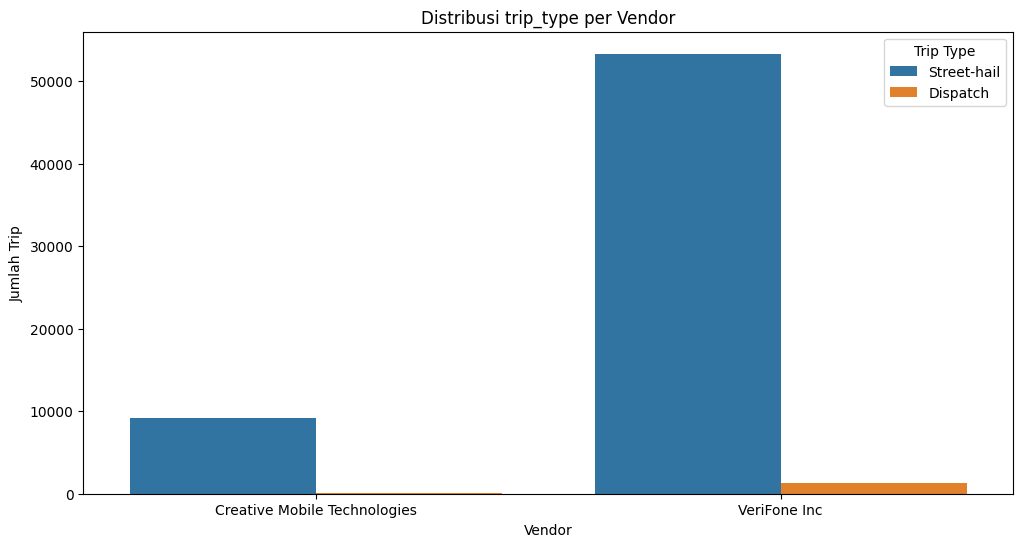

In [25]:
vendor_map = {
    1: "Creative Mobile Technologies",
    2: "VeriFone Inc"
}
trip_type_map = {
    1: "Street-hail",
    2: "Dispatch"
}

# Hitung jumlah trip_type per VendorID
data = df.groupby(['VendorID','trip_type']).size().reset_index(name='count')

# Ganti angka jadi label
data['VendorID'] = data['VendorID'].map(vendor_map)
data['trip_type'] = data['trip_type'].map(trip_type_map)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=data,
            x='VendorID', y='count', hue='trip_type')
plt.title('Distribusi trip_type per Vendor')
plt.ylabel('Jumlah Trip')
plt.xlabel('Vendor')
plt.legend(title='Trip Type')
plt.show()

In [44]:
# Apakah VendorID berpengaruh terhadap trip_type yang dipilih oleh penumpang?

# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

table = pd.crosstab(df['VendorID'],df['trip_type'])
table

# Uji Normalitas
stat_norm, pval_norm = shapiro (df['VendorID'])

if pval_norm < 0.05 :
  print('tolak H0, sehingga data tidak berdistribusi normal')
  print('\n')
else:
  print('gagal tolak H0, sehingga data berdistribusi normal')
  print('\n')

# ==============================================================================================================

# H0: VendorID tidak berpengaruh terhadap trip_type yang dipilih penumpang
# H1: VendorID berpengaruh terhadap trip_type yang dipilih penumpang

# Uji statistik: Hipotesis menggunakan 2 subyek yang berbeda dan data tidak berdistribusi normal  

# Menggunakan metode mannwhitneyu

stat, p = mannwhitneyu(
    df[df['VendorID']== '1']['trip_type'],
    df[df['VendorID']== '2']['trip_type'],
    alternative= 'less')

if p < 0.05 :
    print ("Tolak H0, Sehingga VendorID berpengaruh terhadap trip_type yang dipilih penumpang")
    print('=========================================================')
    print('\n')
else :
    print ("Gagal Tolak H0, Sehingga VendorID tidak berpengaruh terhadap trip_type yang dipilih penumpang")
    print('=========================================================')
    print('\n')

vendor = df.groupby('VendorID')['trip_type'].sum()

# ==============================================================================================================

cmt = vendor.get('1', 0)
verifone = vendor.get('2', 0)

print(f"Creative Mobile T echnologies, LLC. (VendorID)): {cmt}")
print('\n')
print(f"VeriFone Inc. (VendorID): {verifone}")
print('\n')

if cmt < verifone:
    print("VendorID berpengaruh terhadap trip_type yang dipilih penumpang.")
    print('\n')
else:
    print("VendorID tidak berpengaruh terhadap trip_type yang dipilih penumpang")
    print('\n')

tolak H0, sehingga data tidak berdistribusi normal


Gagal Tolak H0, Sehingga VendorID tidak berpengaruh terhadap trip_type yang dipilih penumpang


Creative Mobile T echnologies, LLC. (VendorID)): 0


VeriFone Inc. (VendorID): 0


VendorID tidak berpengaruh terhadap trip_type yang dipilih penumpang




Dari data diatas dapat disimpulkan bahwa dari kedua vendor tersebut penumpang yang memilih Street-hail lebih banyak dibanding dengan Dispatch. Hal ini menunjukkan siapapun vendornya, penumpang lebih nyaman Street-hail dibanding Dispatch.

## 2. Berdasarkan lokasi dimana penumpang naik dan turun : `PULocationID` dan `DOLocationID`

Pertama, mari kita lihat bagaimana pengaruh lokasi dimana penumpang naik dan turun terhadap keinginan penumpang memesan NYC TLC langsung di jalan. Kita akan menganalisis kolom  `PULocationID` dan `DOLocationID` untuk menjawab beberapa pertanyaan.

* Zona mana yang paling sering penumpang naik TLC?
* Zona mana yang paling sering penumpang turun TLC?
* Apakah ada perbedaan `PULocationID` dan `DOLocationID` dengan penumpang Dispatch?

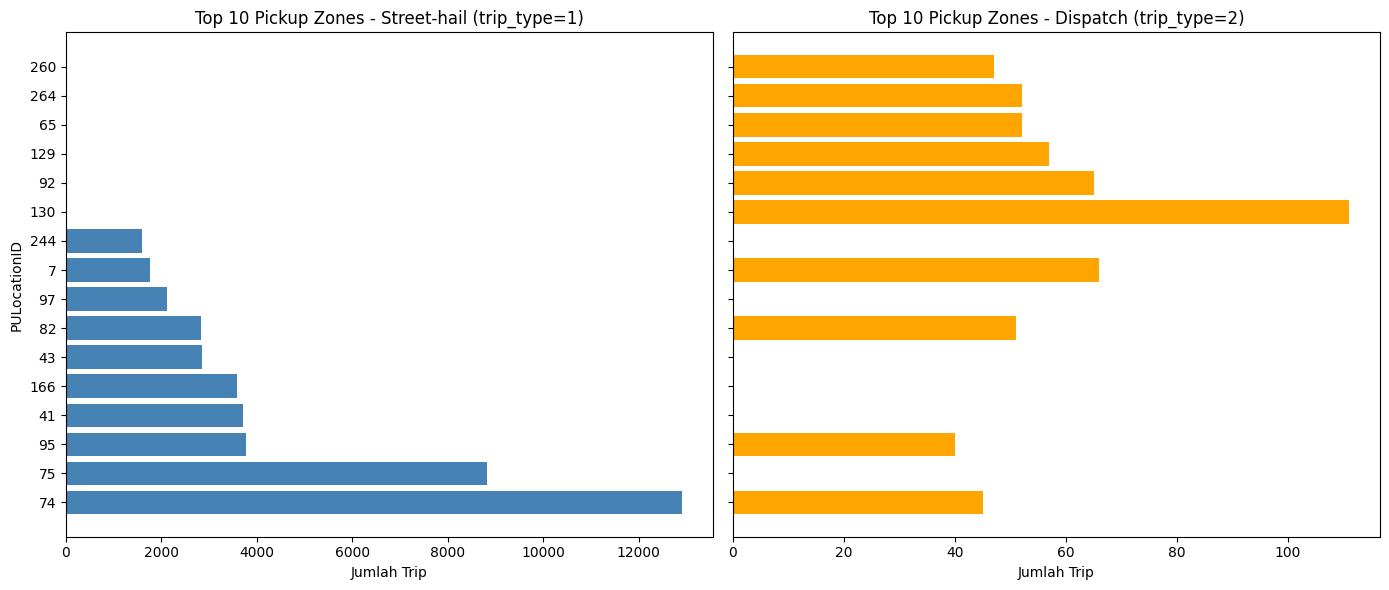

In [27]:
# Zona mana yang paling sering penumpang naik TLC berdasarkan trip_type?

pu1 = df[df['trip_type'] == 1]['PULocationID'].value_counts().head(10)
pu2 = df[df['trip_type'] == 2]['PULocationID'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Street-hail (trip_type=1)
axes[0].barh(pu1.index.astype(str), pu1.values, color="steelblue")
axes[0].set_title("Top 10 Pickup Zones - Street-hail (trip_type=1)")
axes[0].invert_yaxis()
axes[0].set_xlabel("Jumlah Trip")
axes[0].set_ylabel("PULocationID")

# Dispatch (trip_type=2)
axes[1].barh(pu2.index.astype(str), pu2.values, color="orange")
axes[1].set_title("Top 10 Pickup Zones - Dispatch (trip_type=2)")
axes[1].invert_yaxis()
axes[1].set_xlabel("Jumlah Trip")

plt.tight_layout()
plt.show()

In [52]:
# Apakah PULocationID berpengaruh terhadap trip_type yang dipilih oleh penumpang?

# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

table = pd.crosstab(df['PULocationID'],df['trip_type'])
table

# Uji Normalitas
stat_norm, pval_norm = shapiro (df['PULocationID'])

if pval_norm < 0.05 :
  print(f'p-value : {pval_norm}, maka tolak H0, sehingga data tidak berdistribusi normal')
  print('\n')
else:
  print(f'p-value : {pval_norm}, maka gagal tolak H0, sehingga data berdistribusi normal')
  print('\n')

# ==============================================================================================================

# H0: PULocationID tidak berpengaruh terhadap trip_type yang dipilih penumpang
# H1: PULocationID berpengaruh terhadap trip_type yang dipilih penumpang

# Uji statistik: Hipotesis menggunakan 2 subyek yang berbeda dan data tidak berdistribusi normal  

# Menggunakan Chi-square

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

if p < 0.05 :
    print ("Tolak H0, Sehingga PULocationID berpengaruh terhadap trip_type yang dipilih penumpang")
else :
    print ("Gagal Tolak H0, Sehingga PULocationID tidak berpengaruh terhadap trip_type yang dipilih penumpang")


p-value : 8.943949926731236e-115, maka tolak H0, sehingga data tidak berdistribusi normal


Chi-square: 5786.683328264606
p-value: 0.0
Tolak H0, Sehingga PULocationID berpengaruh terhadap trip_type yang dipilih penumpang


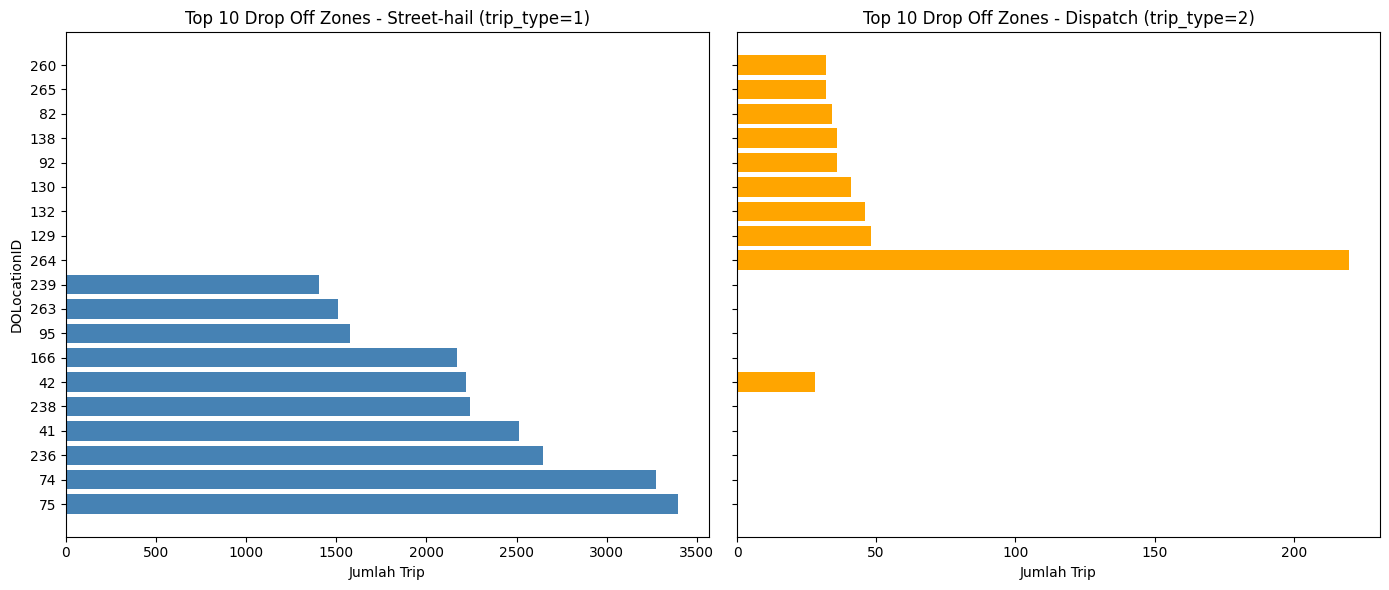

In [28]:
# Zona mana yang paling sering penumpang turun TLC?
do1 = df[df['trip_type'] == 1]['DOLocationID'].value_counts().head(10)
do2 = df[df['trip_type'] == 2]['DOLocationID'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Street-hail (trip_type=1)
axes[0].barh(do1.index.astype(str), do1.values, color="steelblue")
axes[0].set_title("Top 10 Drop Off Zones - Street-hail (trip_type=1)")
axes[0].invert_yaxis()
axes[0].set_xlabel("Jumlah Trip")
axes[0].set_ylabel("DOLocationID")

# Dispatch (trip_type=2)
axes[1].barh(do2.index.astype(str), do2.values, color="orange")
axes[1].set_title("Top 10 Drop Off Zones - Dispatch (trip_type=2)")
axes[1].invert_yaxis()
axes[1].set_xlabel("Jumlah Trip")

plt.tight_layout()
plt.show()

In [53]:
# Apakah DOLocationID berpengaruh terhadap trip_type yang dipilih oleh penumpang?

# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

table = pd.crosstab(df['DOLocationID'],df['trip_type'])
table

# Uji Normalitas
stat_norm, pval_norm = shapiro (df['DOLocationID'])

if pval_norm < 0.05 :
  print(f'p-value : {pval_norm}, maka tolak H0, sehingga data tidak berdistribusi normal')
  print('\n')
else:
  print(f'p-value : {pval_norm}, maka gagal tolak H0, sehingga data berdistribusi normal')
  print('\n')

# ==============================================================================================================

# H0: PULocationID tidak berpengaruh terhadap trip_type yang dipilih penumpang
# H1: PULocationID berpengaruh terhadap trip_type yang dipilih penumpang

# Uji statistik: Hipotesis menggunakan 2 subyek yang berbeda dan data tidak berdistribusi normal  

# Menggunakan Chi-square

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

if p < 0.05 :
    print ("Tolak H0, Sehingga DOLocationID berpengaruh terhadap trip_type yang dipilih penumpang")
else :
    print ("Gagal Tolak H0, Sehingga DOLocationID tidak berpengaruh terhadap trip_type yang dipilih penumpang")


p-value : 6.0488378358026836e-92, maka tolak H0, sehingga data tidak berdistribusi normal


Chi-square: 7033.8393104867
p-value: 0.0
Tolak H0, Sehingga DOLocationID berpengaruh terhadap trip_type yang dipilih penumpang


### Apakah ada perbedaan `PULocationID` dan `DOLocationID` dari masing-masing trip_type yang dipilih penumpang?

Ya, Dilihat dari grafik Top 10 PULocationID customer paling banyak naik di zona 74, diikuti dengan Zona 75, 95, 41, 166, 43, 82, 97, 7 dan 244. Sedangkan untuk Dispatch, penumpang paling banyak naik di zona 130 diikuti dengan zona 97, 92, 129, 264, 65, 82, 260, 74 dan 95. Dan setelah dilihat dari grafik Top 10 PULocationID customer paling banyak turun di zona 74 diikuti dengan zona 75, 95, 41, 166, 43, 82, 97, 7 dan 244. Sedangkan untuk penumpang Dispatch, penumpang paling banyak turun di zona 130 diikuti dengan zona 7, 92, 97, 129, 65, 264, 260, 74 dan 95.

### Perbedaan jumlah lokasi unik dapat menunjukkan bahwa:
* Street-hail cenderung terjadi di area tertentu (mis. pusat kota) → variasi lokasi lebih sempit.
* Dispatch bisa menjangkau lebih banyak titik penjemputan/penurunan karena pemesanan via sistem.

## 3. Berdasarkan waktu saat penumpang naik: `lpep_pickup_datetime`

Berikutnya, mari kita lihat fitur-fitur yang berkaitan dengan edukasi. Fitur yang terkait adalah `lpep_pickup_datetime`.

Kita bisa menjawab pertanyaan-pertanyaan berikut dalam analisis kali ini: **Kapan penumpang lebih sering memesan TLC?**

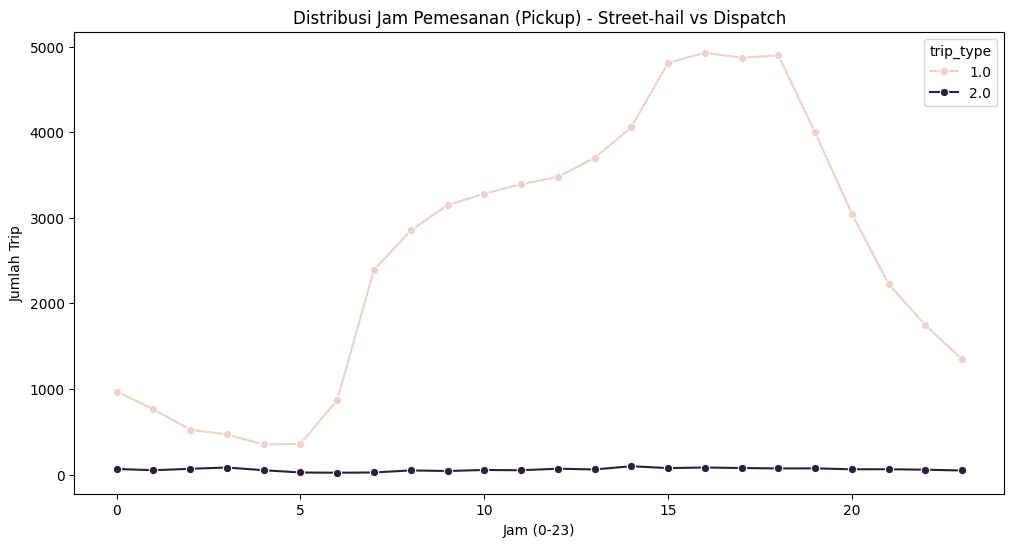

In [29]:
df['pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime']) 
df['pickup_hour'] = df['pickup_datetime'].dt.hour

pickup_hourly = df.groupby(['trip_type','pickup_hour']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.lineplot(data=pickup_hourly, x='pickup_hour', y='count', hue='trip_type', marker='o')
plt.title("Distribusi Jam Pemesanan (Pickup) - Street-hail vs Dispatch")
plt.xlabel("Jam (0-23)")
plt.ylabel("Jumlah Trip")
plt.show()

In [56]:
# Apakah lpep_pickup_datetime berpengaruh terhadap trip_type yang dipilih oleh penumpang?

# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

# Buat variabel jam dari pickup datetime
df['pickup_hour'] = pd.to_datetime(df['lpep_pickup_datetime']).dt.hour

table = pd.crosstab(df['pickup_hour'],df['trip_type'])
table

# Uji Normalitas
stat_norm, pval_norm = shapiro (df['pickup_hour'])

if pval_norm < 0.05 :
  print(f'p-value : {pval_norm}, maka tolak H0, sehingga data tidak berdistribusi normal')
  print('\n')
else:
  print(f'p-value : {pval_norm}, maka gagal tolak H0, sehingga data berdistribusi normal')
  print('\n')

# ==============================================================================================================

# H0: lpep_pickup_datetime tidak berpengaruh terhadap trip_type yang dipilih penumpang
# H1: lpep_pickup_datetime berpengaruh terhadap trip_type yang dipilih penumpang

# Uji statistik: Hipotesis menggunakan 2 subyek yang berbeda dan data tidak berdistribusi normal  

# Menggunakan Chi-square

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

if p < 0.05 :
    print ("Tolak H0, Sehingga lpep_pickup_datetime berpengaruh terhadap trip_type yang dipilih penumpang")
else :
    print ("Gagal Tolak H0, Sehingga lpep_pickup_datetime tidak berpengaruh terhadap trip_type yang dipilih penumpang")


p-value : 8.464621220522727e-75, maka tolak H0, sehingga data tidak berdistribusi normal


Chi-square: 1131.0729579194458
p-value: 1.6751853349294043e-224
Tolak H0, Sehingga lpep_pickup_datetime berpengaruh terhadap trip_type yang dipilih penumpang


### Dari hasil analisis diatas bisa disimpulkan bahwa :
* Street-hail biasanya lebih sering di jam sibuk, dilihat dari jam berangkat hingga pulang kerja.
* Dispatch lebih banyak dipesan pada malam hingga dini hari atau perjalanan terjadwal (misalnya ke bandara pada pagi hari).
* Pola dropoff akan mengikuti pickup tapi bisa bergeser beberapa jam sesuai durasi perjalanan.

## 4. Berdasarkan Jarak : `trip_distance`

Berikutnya, mari kita lihat fitur-fitur yang berkaitan dengan Jarak. Fitur yang terkait adalah `trip_distance`.

* Berapa besar perbedaan pemesanan Street Hail dan Dispatch berdasarkan `trip_distance`?
* Apakah jarak berpengaruh terhadap pilihan penumpang untuk lebih memilih Street hail dibanding Dispatch?

             count      mean       std  min   25%   50%   75%      max
trip_type                                                             
1.0        62476.0  2.578122  6.799769  0.0  1.11  1.80  3.05  1571.97
2.0         1401.0  2.525746  4.671636  0.0  0.00  0.18  3.20    48.70


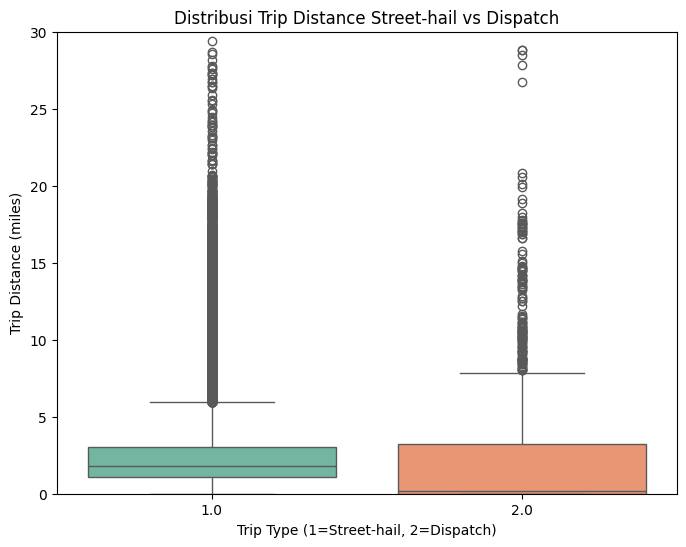

In [30]:
# Berapa besar perbedaan pemesanan Street Hail dan Dispatch berdasarkan `trip_distance`?

# Statistik deskriptif
print(df.groupby("trip_type")['trip_distance'].describe())

# Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="trip_type", y="trip_distance", palette="Set2")
plt.ylim(0, 30)  # batasi agar tidak outlier ekstrem
plt.title("Distribusi Trip Distance Street-hail vs Dispatch")
plt.xlabel("Trip Type (1=Street-hail, 2=Dispatch)")
plt.ylabel("Trip Distance (miles)")
plt.show()


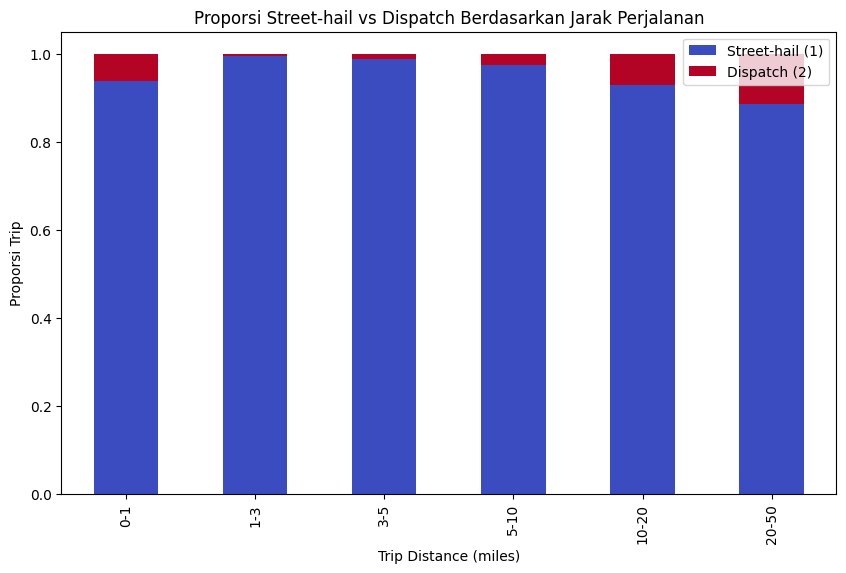

In [31]:
# Apakah jarak berpengaruh terhadap pilihan penumpang untuk lebih memilih Street hail dibanding Dispatch?

# Membuat kategori jarak
bins = [0, 1, 3, 5, 10, 20, 50]
labels = ["0-1", "1-3", "3-5", "5-10", "10-20", "20-50"]
df['distance_bin'] = pd.cut(df['trip_distance'], bins=bins, labels=labels, right=False)

# Hitung proporsi
distance_prop = df.groupby(['distance_bin','trip_type']).size().reset_index(name='count')
distance_prop = distance_prop.pivot(index='distance_bin', columns='trip_type', values='count').fillna(0)
distance_prop = distance_prop.div(distance_prop.sum(axis=1), axis=0)  # ubah ke proporsi

# Plot
distance_prop.plot(kind='bar', stacked=True, figsize=(10,6), colormap="coolwarm")
plt.title("Proporsi Street-hail vs Dispatch Berdasarkan Jarak Perjalanan")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Proporsi Trip")
plt.legend(["Street-hail (1)", "Dispatch (2)"])
plt.show()


In [62]:
# Apakah trip_distance berpengaruh terhadap trip_type yang dipilih oleh penumpang?

# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

# Pisahkan data berdasarkan trip_type
dist1 = df[df['trip_type'] == 1]['trip_distance']
dist2 = df[df['trip_type'] == 2]['trip_distance']
n_sample = min(len(dist1), len(dist2), 5000)

# Uji normalitas untuk tiap grup
stat1, p1 = shapiro(dist1.sample(n_sample, random_state=42))
stat2, p2 = shapiro(dist2.sample(n_sample, random_state=42))

# Hasil uji normalitas untuk trip_type = 1
if p1 < 0.05:
    print(f'p-value (trip_type=1): {p1}, maka Tolak H0 → data tidak berdistribusi normal\n')
else:
    print(f'p-value (trip_type=1): {p1}, maka Gagal Tolak H0 → data berdistribusi normal\n')

# Hasil uji normalitas untuk trip_type = 2
if p2 < 0.05:
    print(f'p-value (trip_type=2): {p2}, maka Tolak H0 → data tidak berdistribusi normal\n')
else:
    print(f'p-value (trip_type=2): {p2}, maka Gagal Tolak H0 → data berdistribusi normal\n')


# ============================================================
# Hipotesis Pengaruh
# H0: trip_distance tidak berpengaruh terhadap trip_type
# H1: trip_distance berpengaruh terhadap trip_type
# ============================================================

# Jika kedua grup normal → gunakan t-test
# Jika salah satu tidak normal → gunakan Mann-Whitney
if p1 > 0.05 and p2 > 0.05:
    stat, p = ttest_ind(dist1, dist2)
    print("Uji t-test")
else:
    stat, p = mannwhitneyu(dist1, dist2)
    print("Uji Mann-Whitney")

print("statistik:", stat)
print("p-value:", p)

# Interpretasi hasil
if p < 0.05:
    print("Tolak H0 → trip_distance berpengaruh terhadap trip_type")
else:
    print("Gagal Tolak H0 → trip_distance tidak berpengaruh signifikan terhadap trip_type")


p-value (trip_type=1): 6.243143953660185e-42, maka Tolak H0 → data tidak berdistribusi normal

p-value (trip_type=2): 4.389085320077944e-49, maka Tolak H0 → data tidak berdistribusi normal

Uji Mann-Whitney
statistik: 58373817.0
p-value: 1.219100209785398e-101
Tolak H0 → trip_distance berpengaruh terhadap trip_type


### Dari hasil analisis diatas bisa disimpulkan, bahwa :
* Street-hail biasanya dipakai untuk jarak pendek (mis. < 3-5 miles) → orang langsung cegat taksi di jalan.
* Dispatch lebih dominan di jarak jauh (5+ miles) → karena orang pesan untuk perjalanan ke bandara atau perjalanan terencana.

## 5. Berdasarkan Tarif yang dibayar customer : `RatecodeID`, `tip_amount`, `total_amount` dan `payment_type`.

Berikutnya, mari kita lihat fitur-fitur yang berkaitan dengan Tarif. Fitur yang terkait adalah `RatecodeID`, `tip_amount` dan `total_amount`.

* Apakah terdapat perbedaan jumlah penumpang Street hail dan Dispatch berdasarkan `Ratecode`?
* Apakah terdapat perbedaan jumlah penumpang Street hail dan Dispatch berdasarkan `tip_amount`?
* Apakah `tip_amount` berpengaruh dengan `payment_type` yang dipilih penumpang?
* Apakah terdapat perbedaan jumlah penumpang Street hail dan Dispatch berdasarkan `total_amount`?
* Apakah 3 hal tersebut berpengaruh dengan pilihan customer dalam memilih antara Street hail dan Dispatch?

In [32]:
# Apakah terdapat perbedaan jumlah penumpang Street hail dan Dispatch berdasarkan `Ratecode`?

df.groupby(['trip_type','RatecodeID']).size().reset_index(name='count')

,trip_type,RatecodeID,count
0,1.0,1.0,62097
1,1.0,2.0,158
2,1.0,3.0,30
3,1.0,4.0,55
4,1.0,5.0,136
5,2.0,1.0,6
6,2.0,4.0,2
7,2.0,5.0,1393


BIsa dilihat dari tabel diatas bahwa Street-hail lebih dominan di Standard Rate, Dispatch lebih ke negotiated rate.

In [33]:
# Apakah terdapat perbedaan jumlah penumpang Street hail dan Dispatch berdasarkan `tip_amount`?

df.groupby('trip_type')['tip_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
trip_type,,,,,,,,
1.0,62476.0,2.033023,2.946142,0.0,0.0,1.46,3.22,222.22
2.0,1401.0,2.441492,4.764369,0.0,0.0,0.00,3.09,59.20


Dari data diatas dapat disimpulkan bahwa Dispatch (card payment) lebih tinggi tip, Street-hail (cash) lebih sering tip = 0.

In [34]:
# Apakah `tip_amount` berpengaruh dengan `payment_type` yang dipilih penumpang?

df.groupby('payment_type')['tip_amount'].mean().reset_index()

,payment_type,tip_amount
0,1.0,3.205830
1,2.0,0.000221
2,3.0,0.019703
3,4.0,0.221053
4,5.0,0.000000


Dari data diatas dapat disimpulkan bahwa jenis pembayaran jelas memengaruhi tip.

In [35]:
# Apakah terdapat perbedaan jumlah penumpang Street hail dan Dispatch berdasarkan `total_amount`?

df.groupby('trip_type')['total_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
trip_type,,,,,,,,
1.0,62476.0,21.204938,13.612114,0.0,12.8,17.7,25.69,349.6
2.0,1401.0,34.209258,44.605989,0.0,14.0,21.0,40.00,491.0


Dari data diatas dapat disimpulkan bahwa Dispatch cenderung jarak jauh → total lebih tinggi.

In [36]:
# Apakah 3 hal tersebut berpengaruh dengan pilihan customer dalam memilih antara Street hail dan Dispatch?

# Pilih variabel
X = df[['RatecodeID','tip_amount','total_amount']]
y = df['trip_type']

# Preprocessing
X = X.fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split & model
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))
print("Coef (importance):", model.coef_)

Accuracy: 0.9977562095595909
Coef (importance): [[ 1.83619957  0.02601888 -0.00326431]]


Secara umum, ketiga faktor tersebut memang bisa berpengaruh pada kecenderungan pelanggan memilih Street-hail atau Dispatch.

## 6. Berdasarkan Banyaknya penumpang : `passenger_count`

* Apakah terdapat perbedaan `passenger_count` antara penumpang Street hail dengan Dispatch?
* Apakah `passenger_count` berpengaruh dengan pilihan customer menjadi Street hail?

             count      mean       std  min  25%  50%  75%  max
trip_type                                                      
1.0        62476.0  1.316169  0.981621  0.0  1.0  1.0  1.0  6.0
2.0         1401.0  1.304782  0.860589  0.0  1.0  1.0  1.0  9.0


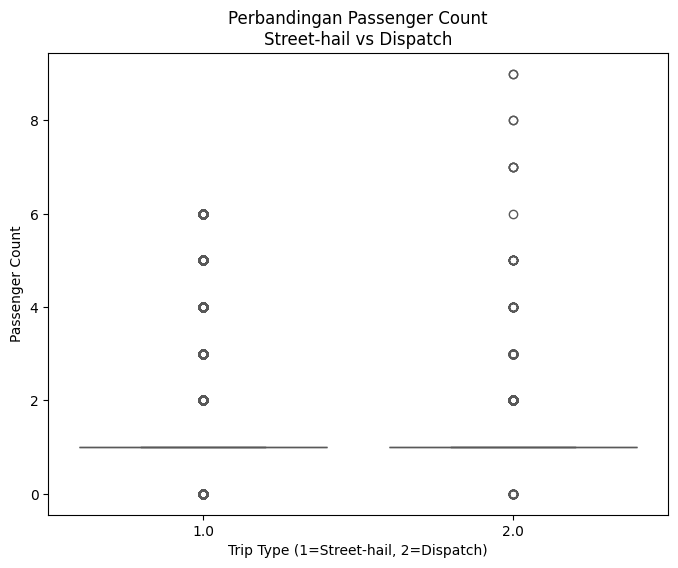

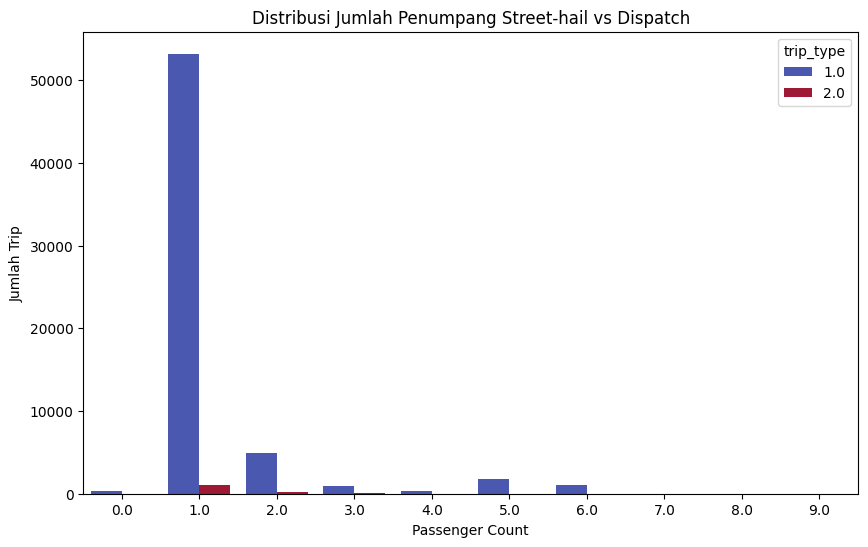

In [37]:
# Apakah terdapat perbedaan `passenger_count` antara penumpang Street hail dengan Dispatch?

# Statistik deskriptif
print(df.groupby('trip_type')['passenger_count'].describe())

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='trip_type', y='passenger_count', palette="Set2")
plt.title("Perbandingan Passenger Count\nStreet-hail vs Dispatch")
plt.xlabel("Trip Type (1=Street-hail, 2=Dispatch)")
plt.ylabel("Passenger Count")
plt.show()

# Distribusi dalam bar chart
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='passenger_count', hue='trip_type', palette="coolwarm")
plt.title("Distribusi Jumlah Penumpang Street-hail vs Dispatch")
plt.xlabel("Passenger Count")
plt.ylabel("Jumlah Trip")
plt.show()


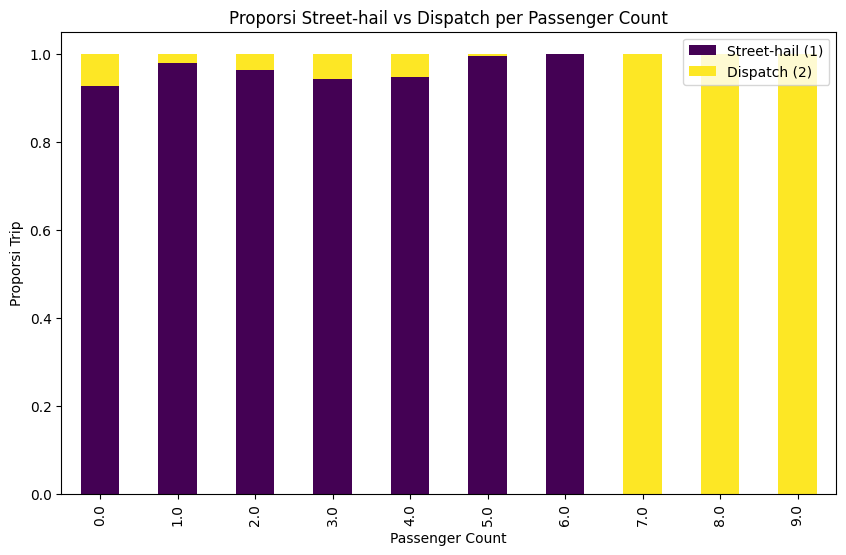

In [38]:
# Apakah `passenger_count` berpengaruh dengan pilihan customer menjadi Street hail?

prop_passenger = df.groupby(['passenger_count','trip_type']).size().reset_index(name='count')
prop_passenger = prop_passenger.pivot(index='passenger_count', columns='trip_type', values='count').fillna(0)
prop_passenger = prop_passenger.div(prop_passenger.sum(axis=1), axis=0)

prop_passenger.plot(kind='bar', stacked=True, figsize=(10,6), colormap="viridis")
plt.title("Proporsi Street-hail vs Dispatch per Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Proporsi Trip")
plt.legend(["Street-hail (1)", "Dispatch (2)"])
plt.show()


In [58]:
# Apakah passenger_count berpengaruh terhadap trip_type yang dipilih oleh penumpang?

# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

table = pd.crosstab(df['passenger_count'],df['trip_type'])
table

# Uji Normalitas
stat_norm, pval_norm = shapiro (df['passenger_count'])

if pval_norm < 0.05 :
  print(f'p-value : {pval_norm}, maka tolak H0, sehingga data tidak berdistribusi normal')
  print('\n')
else:
  print(f'p-value : {pval_norm}, maka gagal tolak H0, sehingga data berdistribusi normal')
  print('\n')

# ==============================================================================================================

# H0: passenger_count tidak berpengaruh terhadap trip_type yang dipilih penumpang
# H1: passenger_count berpengaruh terhadap trip_type yang dipilih penumpang

# Uji statistik: Hipotesis menggunakan 2 subyek yang berbeda dan data tidak berdistribusi normal  

# Menggunakan Chi-square

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

if p < 0.05 :
    print ("Tolak H0, Sehingga passenger_count berpengaruh terhadap trip_type yang dipilih penumpang")
else :
    print ("Gagal Tolak H0, Sehingga passenger_count tidak berpengaruh terhadap trip_type yang dipilih penumpang")


p-value : 4.3599482987980825e-155, maka tolak H0, sehingga data tidak berdistribusi normal


Chi-square: 565.3806131486626
p-value: 5.603958934763722e-116
Tolak H0, Sehingga passenger_count berpengaruh terhadap trip_type yang dipilih penumpang


Dari data diatas dapat disimpulkan bahwa jumlah penumpang Street Hail cenderung penumpang yang sendirian, sedangkan Dispatch lebih banyak dipakai untuk keluarga/grup (2–4 orang) atau perjalanan terencana.

# Kesimpulan dan Rekomendasi

### Kesimpulan

* Vendor: Mayoritas transaksi berasal dari VeriFone Inc dibanding Creative Mobile Technologies (CMT).
* Trip Type: Transaksi lebih banyak terjadi pada Street-hail (langsung di jalan) daripada Dispatch (pemesanan).
* Penumpang: Sebagian besar perjalanan dilakukan dengan 1–2 penumpang.
* Distribusi Jarak: Banyak perjalanan ada di rentang jarak pendek (0–3 miles), menunjukkan pola penggunaan untuk perjalanan singkat.
* Pembayaran: Kartu kredit paling dominan, sedangkan cash mulai jarang digunakan.
* Tip Amount: Ada hubungan positif antara jarak perjalanan dengan jumlah tip, semakin jauh semakin besar kemungkinan tip.

### Rekomendasi

* Strategi Vendor: Fokus kerja sama dengan VeriFone karena kontribusinya besar, tapi tetap evaluasi layanan CMT.
* Optimasi armada: Tempatkan armada lebih banyak di lokasi-lokasi strategis dengan permintaan tinggi (berdasarkan top pick-up locations).
* Penguatan sistem pembayaran cashless: Mengingat mayoritas penumpang menggunakan kartu kredit, perlu ditingkatkan kecepatan dan keandalan sistem.
* Peningkatan kualitas Dispatch: Karena proporsinya masih sangat kecil, perusahaan bisa memberikan promosi/inovasi agar lebih banyak penumpang menggunakan Dispatch (misalnya lewat aplikasi).
* Strategi peningkatan tip: Latih driver untuk menjaga layanan di perjalanan jarak jauh agar peluang tip lebih tinggi.
* Monitoring waktu sibuk: Menambah armada di jam sibuk (rush hour) untuk mengurangi waktu tunggu penumpang dan meningkatkan kepuasan.
